In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from scipy.stats import spearmanr, ttest_ind
from collections import Counter
from dataset import *
from rmap import *
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

TICKLABEL_FONTDICT = {
    "fontsize":6,
    "fontfamily":"arial"
}
AXISLABEL_FONTDICT = {
    "fontsize":6,
    "fontfamily":"arial",
    "fontweight":"bold"
}

In [2]:
### Copying parts of "evaluate_models()" for quick evaluations of models
full_dataset = SuzukiDataset(from_notebook=True)
n_first_select = 6
# Limiting the evaluations to relatively well-reacting cores for ease of metric usage.
reactivity_class_sum = np.sum(full_dataset.reactivity_array, axis=1)
target_core_inds = [i for i, x in enumerate(reactivity_class_sum) if x > 50]

In [3]:
def unroll_arrays_for_rf(mask, array):
    """Transforms the output array such that it is compatible with random forest classifiers.

    Parameters
    ----------
    mask : np.ndarray
        Values with 1 simulate data that we have not obtained in the training dataset.
    array : np.ndarray
        Input or output values to rearrange for use with conventional models like RF.

    Returns
    -------
    unrolled_array : np.ndarray
        Transformed array.
    """
    if mask is not None:
        if array.ndim == 2:
            return array[mask != 1].flatten()
        elif array.ndim == 3:
            indiv_arrays = []
            for i, j in zip(np.where(mask != 1)[0], np.where(mask != 1)[1]):
                indiv_arrays.append(array[i, j, :])
            return np.vstack(tuple(indiv_arrays))
    else:
        if array.ndim == 2:
            return array.flatten()
        elif array.ndim == 3:
            indiv_arrays = []
            for i in range(array.shape[0]):
                for j in range(array.shape[1]):
                    indiv_arrays.append(array[i, j, :])
            return np.vstack(tuple(indiv_arrays))

In [ ]:
# Making prediction on remaining 59 BBs after sampling 10 BBs with the core of interest with binary classification.
roc_auc_arrays = [[], [], [], []]
reps = ["ohe", "random", "fp", "desc"]

for target_core_ind in target_core_inds :
    print(f"--------------------------------Evaluating on Core {target_core_ind+1}--------------------------------")
    bootstrap_rmap = ReactivityMap(
        source_core_inds=None,
        target_core_ind=target_core_ind,
        test_bb_inds=[],
        dataset=SuzukiDataset(from_notebook=True)
    )
    for j, rep in tqdm(enumerate(reps)):
        if rep == "ohe":
            X_array = full_dataset.X_ohe
        elif rep == "random":
            X_array = full_dataset.X_random
        elif rep == "fp":
            X_array = full_dataset.X_fp
        elif rep == "desc":
            X_array = full_dataset.X_desc
        y_array = full_dataset.reactivity_array
        source_X = unroll_arrays_for_rf(None, X_array[bootstrap_rmap.source_core_inds])
        source_y = unroll_arrays_for_rf(None, y_array[bootstrap_rmap.source_core_inds])
        roc_auc_array = np.zeros(20)

        for i in range(20) :
            np.random.seed(42+i)
            # Selecting 10 random BBs to initially sample for the new core
            selected_bb_inds = np.random.choice(np.arange(69), 10, False)
            remaining_inds = [x for x in range(69) if x not in selected_bb_inds]
        
            gcv = GridSearchCV(
                RandomForestClassifier(random_state=42+i),
                param_grid={"n_estimators":[10, 20, 50, 100], "max_depth":[2,3,5,None]},
                scoring="accuracy",
                n_jobs=-1,
                cv=5
            )

            target_X = X_array[target_core_ind][selected_bb_inds]
            target_y = y_array[target_core_ind][selected_bb_inds]
            combined_y = np.concatenate((source_y, target_y))
            combined_y[combined_y == 2] = 1
            gcv.fit(
                np.vstack((source_X, target_X)), 
                combined_y
            )
            
            remaining_target_X = X_array[target_core_ind][remaining_inds]
            remaining_target_y = y_array[target_core_ind][remaining_inds]
            remaining_target_y[remaining_target_y == 2] = 1
            pred_proba = gcv.predict_proba(remaining_target_X)
            roc_auc_array[i] = roc_auc_score(remaining_target_y, pred_proba[:, 1])
        
        roc_auc_arrays[j].append(roc_auc_array)

--------------------------------Evaluating on Core 1--------------------------------


0it [00:00, ?it/s]

--------------------------------Evaluating on Core 2--------------------------------


0it [00:00, ?it/s]

--------------------------------Evaluating on Core 4--------------------------------


0it [00:00, ?it/s]

--------------------------------Evaluating on Core 8--------------------------------


0it [00:00, ?it/s]

--------------------------------Evaluating on Core 9--------------------------------


0it [00:00, ?it/s]

In [5]:
# Testing the significance of the differences in ROC AUC values between the models 
# with OHE or random representations and the models with FP or descriptor representations.

# Text accompanying Figure S17
for i, rep in enumerate(["DFT", "Fingerprint"]):
    print(rep)
    for j in range(5):
        _, p_ohe = ttest_ind(roc_auc_arrays[0][j], roc_auc_arrays[i+2][j])
        _, p_rand = ttest_ind(roc_auc_arrays[1][j], roc_auc_arrays[i+2][j])
        print("    ", p_ohe, p_rand)
    print()

DFT
     0.003575779475492736 2.0261543726525834e-07
     5.759035635611578e-08 2.4391825050019284e-10
     3.3804443772563473e-07 0.0008006612059821035
     1.735323722154546e-07 1.273186261825919e-06
     4.2583469384016317e-07 4.742288567450427e-05

Fingerprint
     4.9930576548410664e-08 2.387960022954621e-12
     4.238522386493055e-08 5.427676766676746e-10
     1.066686437277823e-11 4.681498425423777e-09
     4.9953543779748874e-08 1.632337730070479e-07
     7.436521190163346e-12 1.2169742472593059e-09



/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_39154/487528352.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["One-hot", "Random", "Fingerprint", "DFT descriptors"], fontdict=TICKLABEL_FONTDICT)


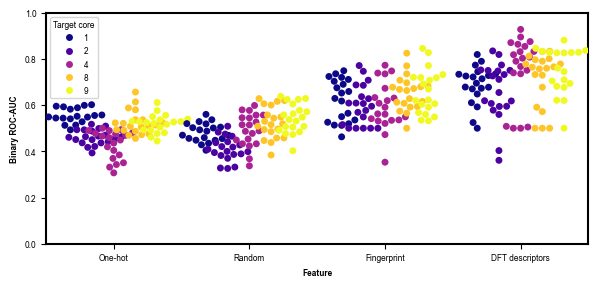

In [6]:
# Plotting the ROC AUC values for the 4 different feature types for each of the 5 cores.
# Figure S17
roc_auc_dict_to_plot = {
    "Core":[],
    "ROC-AUC":[],
    "Feature":[],
    "Trial":[],
}

for i, target_core_ind in enumerate(target_core_inds):
    for j, rep in enumerate(reps) :
        roc_auc_dict_to_plot["Core"].extend([target_core_ind + 1]*20)
        roc_auc_dict_to_plot["ROC-AUC"].extend(list(roc_auc_arrays[j][i]))
        roc_auc_dict_to_plot["Feature"].extend([rep]*20)
        roc_auc_dict_to_plot["Trial"].extend([x+1 for x in range(20)])

roc_df = pd.DataFrame(roc_auc_dict_to_plot)
fig, ax = plt.subplots(figsize=(7, 3))
sns.swarmplot(roc_df, x="Feature", y="ROC-AUC", hue="Core", dodge=True, palette="plasma")
ax.legend(fontsize=6, prop={"size":6, "family":"arial"}, title="Target core", title_fontproperties={"size":6, "family":"arial"})
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticklabels([round(x, 1) for x in np.arange(0, 1.1, 0.2)], fontdict=TICKLABEL_FONTDICT)
ax.set_ylabel("Binary ROC-AUC", fontdict=AXISLABEL_FONTDICT)
ax.set_xticklabels(["One-hot", "Random", "Fingerprint", "DFT descriptors"], fontdict=TICKLABEL_FONTDICT)
ax.set_xlabel("Feature", fontdict=AXISLABEL_FONTDICT)
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
# plt.savefig("../figures/SI/FigureS17_adversarial_control.svg", format="svg", dpi=300)